# Combined DeepLIFT and TF-MoDISco Workflow for TargetGAN Analysis

This notebook implements a comprehensive interpretability workflow for analyzing DNA sequences using **DeepLIFT** and **TF-MoDISco**.

### Workflow Overview:
1.  **Data Loading**: Load trained Keras models and target DNA sequences.
2.  **Importance Scoring**: Use DeepLIFT to calculate contribution scores (importance) for each nucleotide.
3.  **Data Preparation**: Format scores and sequences for TF-MoDISco Analysis.
4.  **Motif Discovery**: Apply TF-MoDISco to cluster high-importance segments (seqlets) into consolidated motifs.
5.  **Visualization & Analysis**: Visualize the discovered motifs and analyze metaclusters.
6.  **Export**: Save motifs in MEME format for downstream analysis.

## Environment Setup
Before running this notebook, please ensure you have created and activated the required conda environment.

```bash
cd ./modisco
conda env create -f ./deeplift_environment.yml
conda activate deeplift
```

> **Note:** This notebook is strictly designed for **TensorFlow 1.14** and **Python 3.6/3.7** due to dependency requirements of DeepLIFT and MoDISco. Do not attempt to run this with TensorFlow 2.x without the compatibility environment.

## 1. Library Imports and Configuration
Import necessary libraries and configure TensorFlow 1.x compatibility mode. Correct setup of `tf.compat.v1` is crucial for DeepLIFT to access the calculation graph.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='-1' # Use CPU
# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import warnings
warnings.filterwarnings('ignore') # Suppress warnings

import tensorflow as tf
import deeplift
from deeplift.conversion import kerasapi_conversion as kc
from deeplift.layers import NonlinearMxtsMode
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd

## 2. Data Loading and Preprocessing
Load the trained predictor model and the input sequences. 
We also define helper functions for **One-Hot Encoding** to convert DNA sequences (A, C, G, T) into the numeric matrix format expected by the 1D-CNN model.

In [2]:
# Helper functions for One-hot encoding
def seq_to_one_hot_fill_in_array(zeros_array, sequence, one_hot_axis):
    assert one_hot_axis==0 or one_hot_axis==1
    if (one_hot_axis==0):
        assert zeros_array.shape[1] == len(sequence)
    elif (one_hot_axis==1): 
        assert zeros_array.shape[0] == len(sequence)
    #will mutate zeros_array
    for (i,char) in enumerate(sequence):
        if (char=="A" or char=="a"):
            char_idx = 0
        elif (char=="C" or char=="c"):
            char_idx = 1
        elif (char=="G" or char=="g"):
            char_idx = 2
        elif (char=="T" or char=="t"):
            char_idx = 3
        elif (char=="N" or char=="n"):
            continue #leave that pos as all 0's
        else:
            raise RuntimeError("Unsupported character: "+str(char))
        if (one_hot_axis==0):
            zeros_array[char_idx,i] = 1
        elif (one_hot_axis==1):
            zeros_array[i,char_idx] = 1

def one_hot_encode_along_channel_axis(sequence):
    to_return = np.zeros((len(sequence),4), dtype=np.int8)
    seq_to_one_hot_fill_in_array(zeros_array=to_return,
                                 sequence=sequence, one_hot_axis=1)
    return to_return

# Load Model and Data
model_path = '../data/predictor.h5' 
sequences_path = '../data/targetgan_55296.xlsx'

if os.path.exists(sequences_path):
    print(f"Loading sequences from {sequences_path}")
    fasta_sequences  = pd.read_excel(sequences_path)['sequence']
    # Perform one-hot encoding
    onehot_data = np.array([one_hot_encode_along_channel_axis(i) for i in fasta_sequences])
    print(f"One-hot data shape: {onehot_data.shape}")
else:
    print(f"Error: Sequences file not found at {sequences_path}")

if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    deeplift_model =kc.convert_model_from_saved_files(
        model_path,
        nonlinear_mxts_mode=deeplift.layers.NonlinearMxtsMode.DeepLIFT_GenomicsDefault)
else:
    print(f"Error: Model file not found at {model_path}")

Loading sequences from ../data/targetgan_55296.xlsx
One-hot data shape: (55296, 170, 4)
Loading model from ../data/predictor.h5
nonlinear_mxts_mode is set to: DeepLIFT_GenomicsDefault

For layer conv1d_404_0 the preceding linear layer is preact_conv1d_404_0 of type Conv1D;
In accordance with nonlinear_mxts_mode=DeepLIFT_GenomicsDefault we are setting the NonlinearMxtsMode to Rescale
For layer conv1d_405_0 the preceding linear layer is preact_conv1d_405_0 of type Conv1D;
In accordance with nonlinear_mxts_mode=DeepLIFT_GenomicsDefault we are setting the NonlinearMxtsMode to Rescale

For layer conv1d_406_0 the preceding linear layer is preact_conv1d_406_0 of type Conv1D;
In accordance with nonlinear_mxts_mode=DeepLIFT_GenomicsDefault we are setting the NonlinearMxtsMode to Rescale
For layer conv1d_407_0 the preceding linear layer is preact_conv1d_407_0 of type Conv1D;
In accordance with nonlinear_mxts_mode=DeepLIFT_GenomicsDefault we are setting the NonlinearMxtsMode to Rescale
For layer 

## 3. DeepLIFT Importance Scoring
Calculate contribution scores for each base in the sequences using DeepLIFT.
*   **Contribution Scores**: The actual importance of the base present in the sequence vs a reference.
*   **Hypothetical Contributions**: The estimated score if a different base were present at that position (required by MoDISco for meaningful clustering).

*Note: This step calculates scores for multiple shuffled references to ensure robustness, which may take some time depending on dataset size.*

MAKING A SESSION




On task 0
4000 reference seqs generated
8000 reference seqs generated
12000 reference seqs generated
16000 reference seqs generated
20000 reference seqs generated
24000 reference seqs generated
28000 reference seqs generated
32000 reference seqs generated
36000 reference seqs generated
40000 reference seqs generated
44000 reference seqs generated
48000 reference seqs generated
52000 reference seqs generated
56000 reference seqs generated
60000 reference seqs generated
64000 reference seqs generated
68000 reference seqs generated
72000 reference seqs generated
76000 reference seqs generated
80000 reference seqs generated
84000 reference seqs generated
88000 reference seqs generated
92000 reference seqs generated
96000 reference seqs generated
100000 reference seqs generated
104000 reference seqs generated
108000 reference seqs generated
112000 reference seqs generated
116000 reference seqs generated
120000 reference seqs generated
124000 reference seqs generated
128

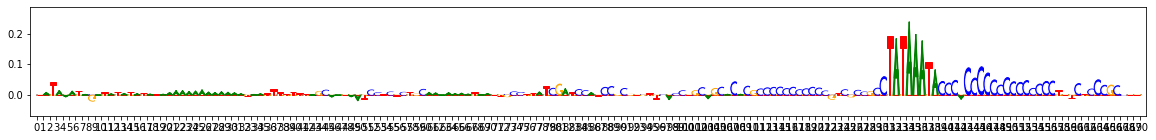

Mean-normalized hypothetical contributions


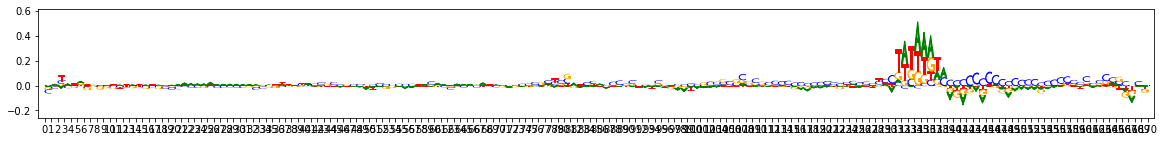

In [3]:
# Compute importance scores
# Compile the DeepLIFT contribution scoring function
from deeplift.util import get_shuffle_seq_ref_function
from deeplift.dinuc_shuffle import dinuc_shuffle #function to do a dinucleotide shuffle
contribs_func = deeplift_model.get_target_contribs_func(
    find_scores_layer_name=list(deeplift_model.get_name_to_layer().keys())[0],
    pre_activation_target_layer_name=list(deeplift_model.get_name_to_layer().keys())[-1])

# Adapt the scoring function to work with multiple shuffled references
contribs_many_refs_func = get_shuffle_seq_ref_function(
    #score_computation_function is the original function to compute scores
    score_computation_function=contribs_func,
    #shuffle_func is the function that shuffles the sequence
    #On real genomic data, a dinuc shuffle is advisable due to
    #the strong bias against CG dinucleotides
    shuffle_func=dinuc_shuffle,
    one_hot_func=lambda x: np.array([one_hot_encode_along_channel_axis(seq)
                                     for seq in x]))

# Compile the "hypothetical" contribution scoring function
from deeplift.util import get_hypothetical_contribs_func_onehot

multipliers_func = deeplift_model.get_target_multipliers_func(
    find_scores_layer_name=list(deeplift_model.get_name_to_layer().keys())[0],
    pre_activation_target_layer_name=list(deeplift_model.get_name_to_layer().keys())[-1])
hypothetical_contribs_func = get_hypothetical_contribs_func_onehot(multipliers_func)

#Once again, we rely on multiple shuffled references
hypothetical_contribs_many_refs_func = get_shuffle_seq_ref_function(
    score_computation_function=hypothetical_contribs_func,
    shuffle_func=dinuc_shuffle,
    one_hot_func=lambda x: np.array([one_hot_encode_along_channel_axis(seq)
                                     for seq in x]))
#%%
# Obtain the scores
num_refs_per_seq = 10
task_to_contrib_scores = {}
task_to_hyp_contrib_scores = {}
all_tasks = [0]
for task_idx in all_tasks:
    print("On task",task_idx)
    task_to_contrib_scores[task_idx] =\
        np.sum(contribs_many_refs_func(
            task_idx=task_idx,
            input_data_sequences=fasta_sequences,
            num_refs_per_seq=num_refs_per_seq,
            batch_size=50,
            progress_update=4000,
        ),axis=2)[:,:,None]*onehot_data
    task_to_hyp_contrib_scores[task_idx] =\
        hypothetical_contribs_many_refs_func(
            task_idx=task_idx,
            input_data_sequences=fasta_sequences,
            num_refs_per_seq=num_refs_per_seq,
            batch_size=50,
            progress_update=4000,
        )

# Visualize the contributions and hypothetical contributions on a few sequences
from deeplift.visualization import viz_sequence

print("Scores for task 0, seq idx 0")
print("Actual contributions")
viz_sequence.plot_weights(task_to_contrib_scores[0][1])
print("Mean-normalized hypothetical contributions")
viz_sequence.plot_weights(task_to_hyp_contrib_scores[0][1])
#%%
# Save the importance scores
import h5py
import os

# if (os.path.isfile("scores.h5")):
#     !rm scores.h5
f = h5py.File("./scores.h5",'w')
g = f.create_group("contrib_scores")
for task_idx in all_tasks:
    g.create_dataset("task"+str(task_idx), data=task_to_contrib_scores[task_idx])
g = f.create_group("hyp_contrib_scores")
for task_idx in all_tasks:
    g.create_dataset("task"+str(task_idx), data=task_to_hyp_contrib_scores[task_idx])
f.close()

## 4. Data Preparation for TF-MoDISco
Prepare the importance scores and hypothetical contributions for TF-MoDISco input. This involves ensuring the data formats (numpy arrays) and shapes are correct.

### 4.1. Data Formatting
TF-MoDISco requires a dictionary mapping task names to numpy arrays of:
- **Importance Scores**: The actual contribution of the sequence.
- **Hypothetical Scores**: The contribution if the base were different (summed/processed).

We also handle reverse-complement augmentation if required by the experimental design.

In [4]:
import h5py
from collections import OrderedDict
import numpy as np

task_to_scores = OrderedDict()
task_to_hyp_scores = OrderedDict()

f = h5py.File("./scores.h5","r")
tasks = f["contrib_scores"].keys() # 'task0'
n = 55296; #since this is just a test run, for speed I am limiting to 100 sequences
#reverse-complement some of the sequences to simulate that
take_rc = (np.random.RandomState(1234).uniform(size=n) > 0.5)
for task in tasks:
    #Note that the sequences can be of variable lengths;
    #in this example they all have the same length (170bp) but that is
    #not necessary.
    task_to_scores[task] = [np.array(x) if not rc else np.array(x)[::-1,::-1]
                            for x,rc in zip(f['contrib_scores'][task][:n], take_rc)]
    task_to_hyp_scores[task] = [np.array(x) if not rc else np.array(x)[::-1,::-1]
                                for x,rc in zip(f['hyp_contrib_scores'][task][:n], take_rc)]

onehot_data = [one_hot_encode_along_channel_axis(seq) if not rc else
               one_hot_encode_along_channel_axis(seq)[::-1,::-1]
               for seq,rc in zip(fasta_sequences[:n], take_rc)]

### Double check by plotting

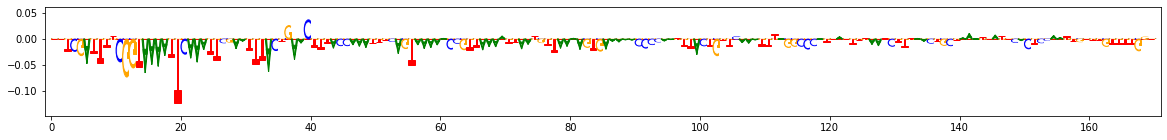

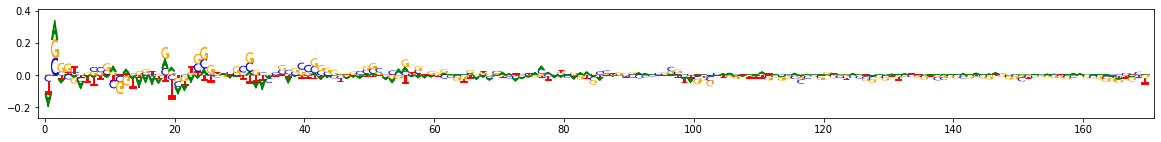

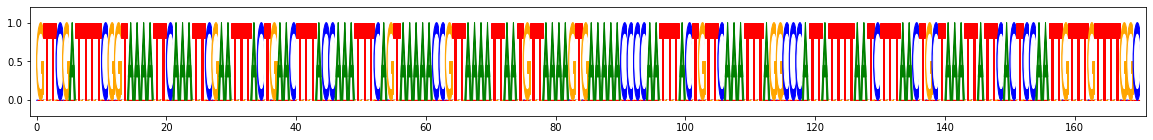

In [5]:
import modisco.visualization
from modisco.visualization import viz_sequence

viz_sequence.plot_weights(task_to_scores['task0'][-1], subticks_frequency=20)
viz_sequence.plot_weights(task_to_hyp_scores['task0'][-1], subticks_frequency=20)
viz_sequence.plot_weights(onehot_data[-1], subticks_frequency=20)

## 5. TF-MoDISco Motif Discovery Workflow
Run the TF-MoDISco pipeline to identify consolidated motifs from the importance scores. This process involves:
1.  **Seqlet Identification**: Finding high-importance chunks.
2.  **Clustering**: Grouping similar seqlets.
3.  **Pattern Aggregation**: Creating a Position Weight Matrix (PWM) for each cluster.

MEMORY 7.84195584
On task task0
Computing windowed sums on original
Generating null dist
peak(mu)= -6.445750594139097e-05
Computing threshold
Subsampling!
For increasing = True , the minimum IR precision was 0.4124236645012492 occurring at 6.705522537231445e-07 implying a frac_neg of 0.7019065261557423
To be conservative, adjusted frac neg is 0.95
For increasing = False , the minimum IR precision was 0.48755415175230116 occurring at -1.9744038581848145e-07 implying a frac_neg of 0.9514257036513916
Thresholds from null dist were -0.5283176302909851  and  0.5547820329666138 with frac passing 0.037195
Final raw thresholds are -0.5283176302909851  and  0.5547820329666138
Final transformed thresholds are -0.9610254816021927  and  0.9630954346313337


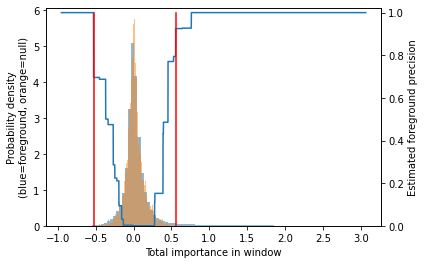

Got 39346 coords
After resolving overlaps, got 39346 seqlets
Across all tasks, the weakest transformed threshold used was: 0.9609254816021927
MEMORY 8.036491264
39346 identified in total
min_metacluster_size_frac * len(seqlets) = 393 is more than min_metacluster_size=100.
Using it as a new min_metacluster_size
2 activity patterns with support >= 393 out of 2 possible patterns
Metacluster sizes:  [37147, 2199]
Idx to activities:  {0: '1', 1: '-1'}
MEMORY 8.036511744
On metacluster 1
Metacluster size 2199
Relevant tasks:  ('task0',)
Relevant signs:  (-1,)
TfModiscoSeqletsToPatternsFactory: seed=1234
(Round 1) num seqlets: 2199
(Round 1) Computing coarse affmat
2026-02-04 18:07:56.985109 MEMORY 8.036511744
Beginning embedding computation
MEMORY 8.036511744
At the beginning of embedding call
2026-02-04 18:07:56.988366 MEMORY 8.036511744
before computing embeddings fwd
2026-02-04 18:07:57.000020 MEMORY 8.036511744


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    5.7s
[Parallel(n_jobs=15)]: Done 170 tasks      | elapsed:   31.7s
[Parallel(n_jobs=15)]: Done 420 tasks      | elapsed:  1.3min
[Parallel(n_jobs=15)]: Done 770 tasks      | elapsed:  2.3min
[Parallel(n_jobs=15)]: Done 1220 tasks      | elapsed:  3.6min
[Parallel(n_jobs=15)]: Done 1770 tasks      | elapsed:  5.2min
[Parallel(n_jobs=15)]: Done 2199 out of 2199 | elapsed:  6.4min finished
[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


after computing embeddings fwd
2026-02-04 18:14:22.053842 MEMORY 8.113270784


[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    3.6s
[Parallel(n_jobs=15)]: Done 170 tasks      | elapsed:   29.6s
[Parallel(n_jobs=15)]: Done 420 tasks      | elapsed:  1.2min
[Parallel(n_jobs=15)]: Done 770 tasks      | elapsed:  2.2min
[Parallel(n_jobs=15)]: Done 1220 tasks      | elapsed:  3.5min
[Parallel(n_jobs=15)]: Done 1770 tasks      | elapsed:  5.1min
[Parallel(n_jobs=15)]: Done 2199 out of 2199 | elapsed:  6.4min finished


after computing embeddings rev
2026-02-04 18:20:44.447248 MEMORY 8.193163264
before computing sparse embeddings fwd
2026-02-04 18:20:44.448615 MEMORY 8.193163264
Constructing csr matrix...
csr matrix made in 0.5038173198699951 s
after computing sparse embeddings fwd
2026-02-04 18:20:45.059590 MEMORY 8.193347584
before computing sparse embeddings rev
2026-02-04 18:20:45.060458 MEMORY 8.193347584
Constructing csr matrix...
csr matrix made in 0.4008185863494873 s
after computing sparse embeddings rev
2026-02-04 18:20:45.529237 MEMORY 8.193478656
Finished embedding computation in 769.6 s
MEMORY 8.14249984
Starting affinity matrix computations
MEMORY 8.14249984
Batching in slices of size 2199


...

Got subclusters: Counter({0: 41, 1: 39, 2: 30, 3: 22, 4: 6})
On pattern 4
[t-SNE] Computing 70 nearest neighbors...
[t-SNE] Indexed 71 samples in 0.003s...
[t-SNE] Computed neighbors for 71 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 71 / 71
[t-SNE] Mean sigma: 0.454465
[t-SNE] Computed conditional probabilities in 0.006s
[t-SNE] Iteration 50: error = 48.4662895, gradient norm = 0.4404354 (50 iterations in 0.359s)
[t-SNE] Iteration 100: error = 50.1126976, gradient norm = 0.4905047 (50 iterations in 0.604s)
[t-SNE] Iteration 150: error = 49.8285789, gradient norm = 0.5624689 (50 iterations in 0.491s)
[t-SNE] Iteration 200: error = 49.6254654, gradient norm = 0.5045144 (50 iterations in 0.497s)
[t-SNE] Iteration 250: error = 47.4801903, gradient norm = 0.5224799 (50 iterations in 0.409s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 47.480190
[t-SNE] Iteration 300: error = 0.7687410, gradient norm = 0.0019775 (50 iterations in 0.489s)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.4s


Parallel Leiden runs finished
2026-02-04 22:55:05.985693 MEMORY 10.31931904
Quality: 0.11616556991655565


[Parallel(n_jobs=15)]: Done  50 out of  50 | elapsed:    0.8s finished


Got subclusters: Counter({0: 25, 2: 13, 1: 13, 3: 12, 4: 6, 5: 2})


In [6]:
import h5py
import numpy as np
%matplotlib inline
import modisco

#Uncomment to refresh modules for when tweaking code during development:
from importlib import reload
reload(modisco.util)
reload(modisco.pattern_filterer)
reload(modisco.aggregator)
reload(modisco.core)
reload(modisco.affinitymat.transformers)
reload(modisco.affinitymat.core)
reload(modisco.affinitymat)
reload(modisco.cluster.core)
reload(modisco.cluster)
reload(modisco.tfmodisco_workflow.seqlets_to_patterns)
reload(modisco.tfmodisco_workflow)
reload(modisco)

null_per_pos_scores = modisco.coordproducers.LaplaceNullDist(num_to_samp=5000)
tfmodisco_results = modisco.tfmodisco_workflow.workflow.TfModiscoWorkflow(
                    #Slight modifications from the default settings
                    sliding_window_size=8,
                    flank_size=3,
                    target_seqlet_fdr=0.15,
                    seqlets_to_patterns_factory=
                     modisco.tfmodisco_workflow.seqlets_to_patterns.TfModiscoSeqletsToPatternsFactory(
                        #Note: as of version 0.5.6.0, it's possible to use the results of a motif discovery
                        # software like MEME to improve the TF-MoDISco clustering. To use the meme-based
                        # initialization, you would specify the initclusterer_factory as shown in the
                        # commented-out code below:
                        #initclusterer_factory=modisco.clusterinit.memeinit.MemeInitClustererFactory(    
                        #    meme_command="meme", base_outdir="meme_out",            
                        #    max_num_seqlets_to_use=10000, nmotifs=10, n_jobs=1),
                        trim_to_window_size=8,
                        initial_flank_to_add=3,
                        final_flank_to_add=0,
                        final_min_cluster_size=30,
                        n_cores=15)
                )(
                 task_names=["task0"],
                 contrib_scores=task_to_scores,
                 hypothetical_contribs=task_to_hyp_scores,
                 one_hot=onehot_data,
                 null_per_pos_scores=null_per_pos_scores)

### 5.1. Save Analysis Results
Persist the full TF-MoDISco results object to an HDF5 file for later analysis or sharing.

In [7]:
import h5py
import modisco.util
reload(modisco.util)
![[ -e results.hdf5 ]] && rm results.hdf5
grp = h5py.File("./results.hdf5", "w")
tfmodisco_results.save_hdf5(grp)
grp.close()

## 6. Analysis and Visualization of Discoveries
Load the results from the HDF5 file and generate visualizations for:
- **Metaclusters**: Overview of the different types of signal found.
- **Motifs (Patterns)**: Detailed view of each discovered motif, including its sequence logo (actual and hypothetical importance).

Metaclusters heatmap


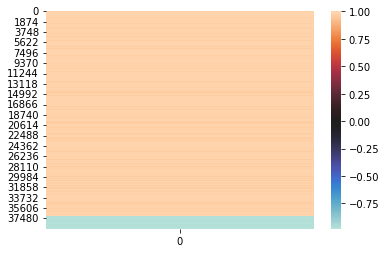

metacluster_0
activity pattern: [1]
metacluster_0 pattern_0
total seqlets: 11094
Task 0 hypothetical scores:


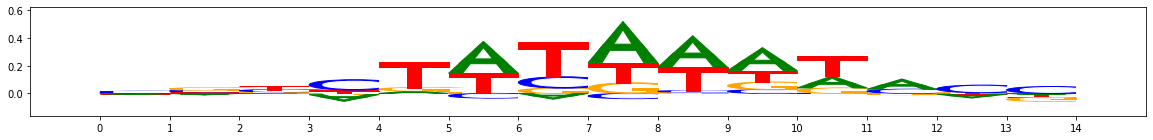

Task 0 actual importance scores:


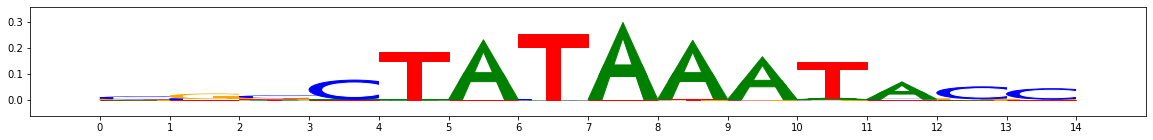

onehot, fwd and rev:


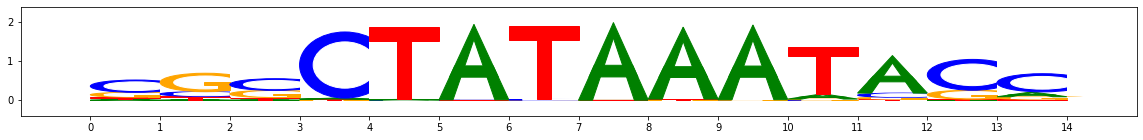

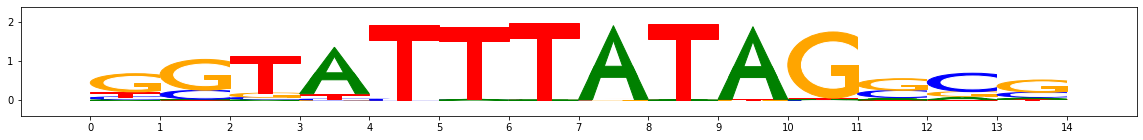

metacluster_0 pattern_1
total seqlets: 3046
Task 0 hypothetical scores:


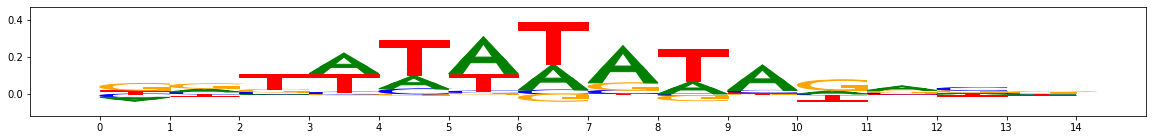

Task 0 actual importance scores:


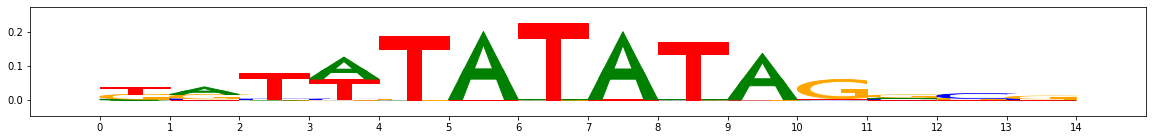

onehot, fwd and rev:


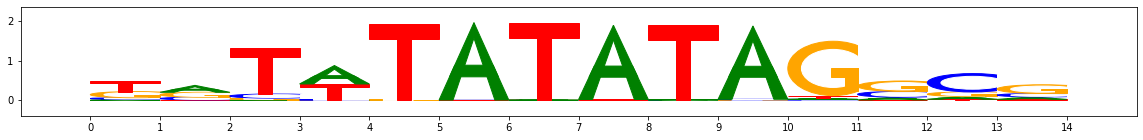

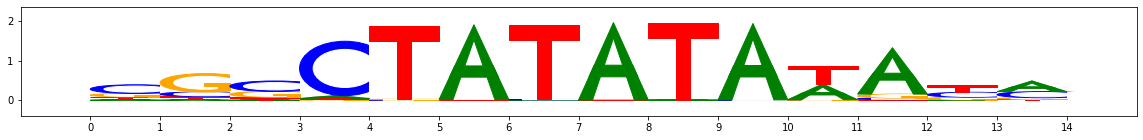

metacluster_0 pattern_2
total seqlets: 253
Task 0 hypothetical scores:


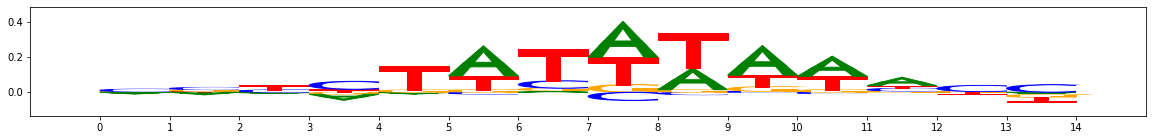

Task 0 actual importance scores:


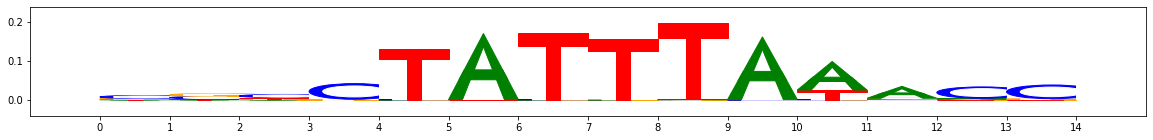

onehot, fwd and rev:


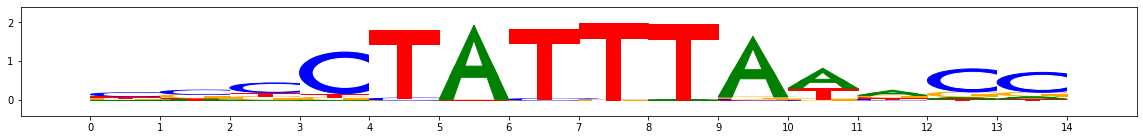

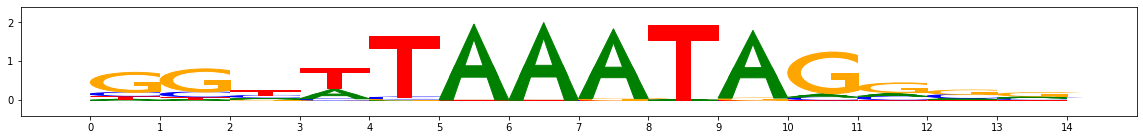

metacluster_0 pattern_3
total seqlets: 138
Task 0 hypothetical scores:


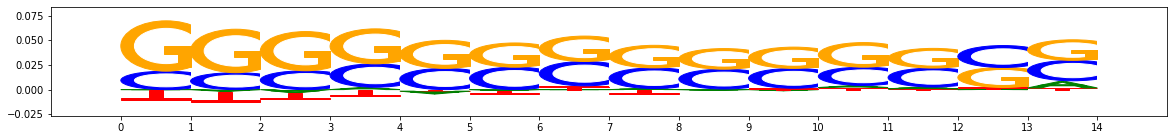

Task 0 actual importance scores:


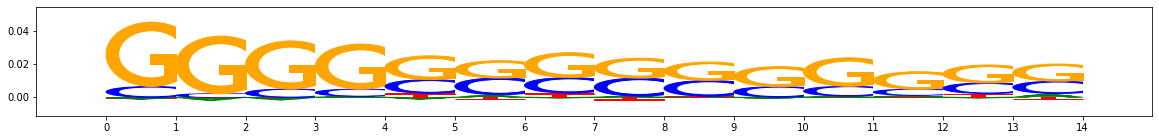

onehot, fwd and rev:


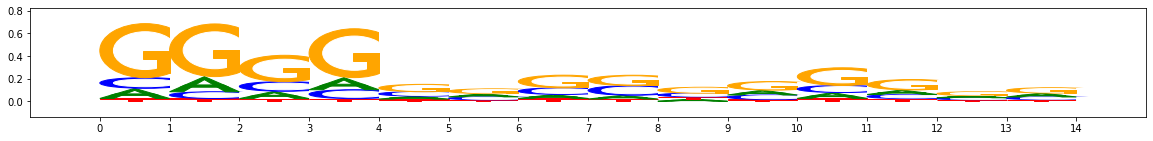

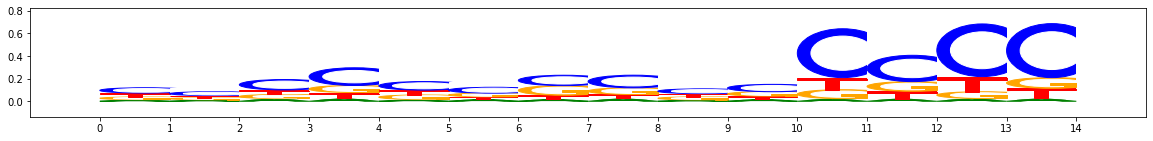

metacluster_0 pattern_4
total seqlets: 71
Task 0 hypothetical scores:


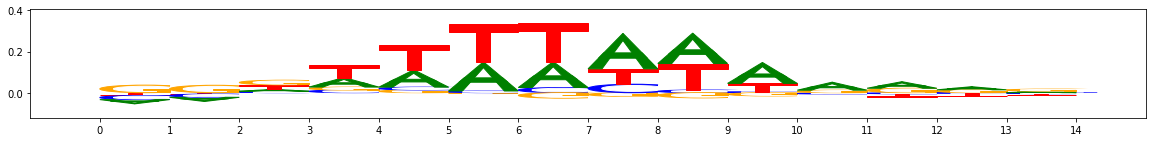

Task 0 actual importance scores:


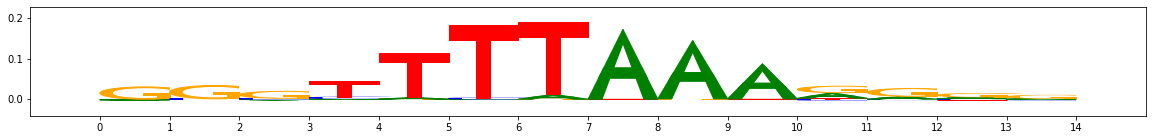

onehot, fwd and rev:


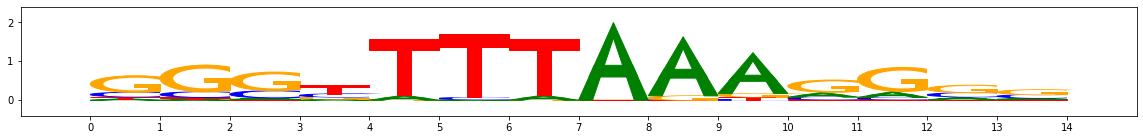

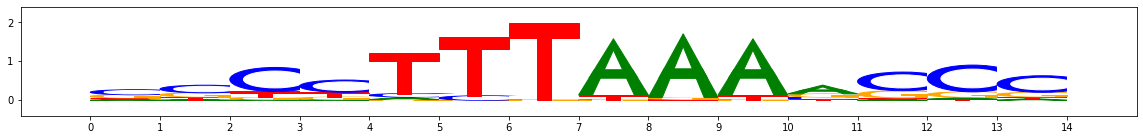

metacluster_1
activity pattern: [-1]
metacluster_1 pattern_0
total seqlets: 677
Task 0 hypothetical scores:


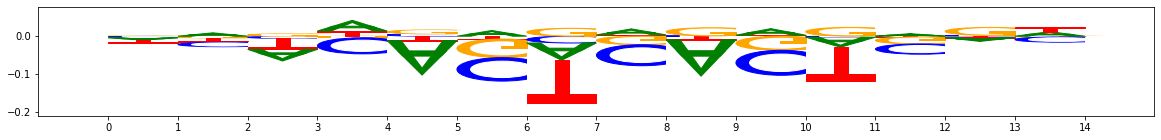

Task 0 actual importance scores:


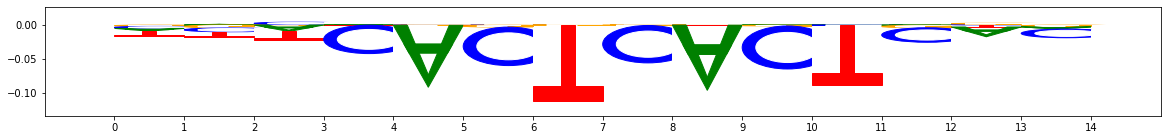

onehot, fwd and rev:


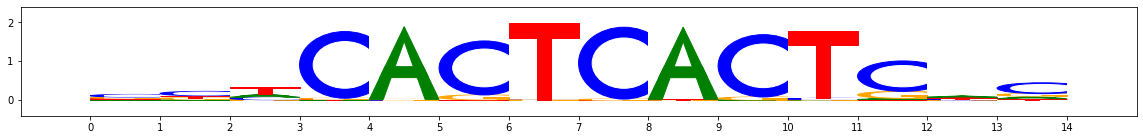

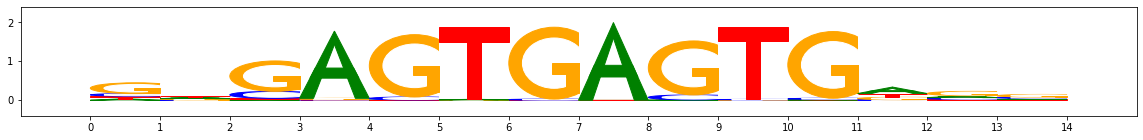

metacluster_1 pattern_1
total seqlets: 237
Task 0 hypothetical scores:


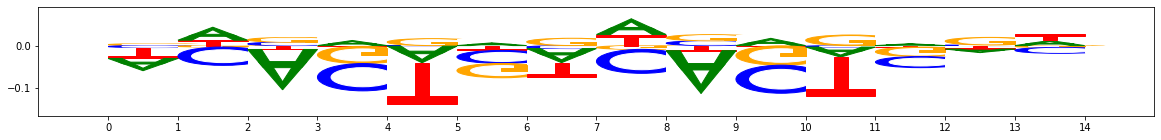

Task 0 actual importance scores:


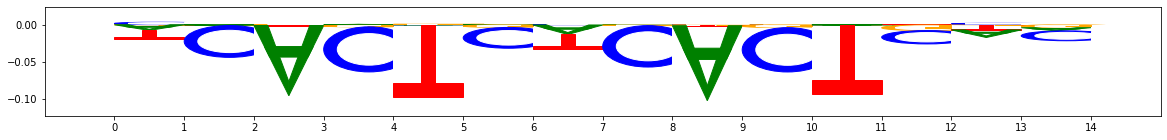

onehot, fwd and rev:


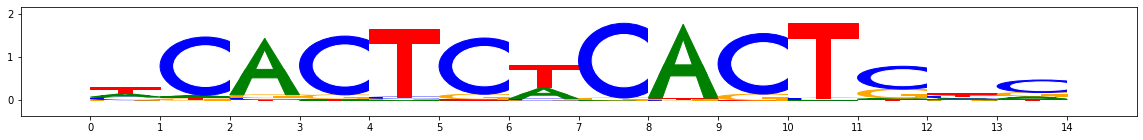

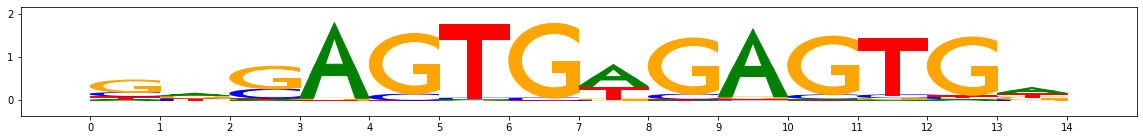

metacluster_1 pattern_2
total seqlets: 111
Task 0 hypothetical scores:


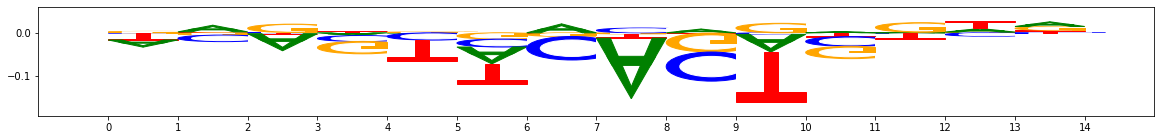

Task 0 actual importance scores:


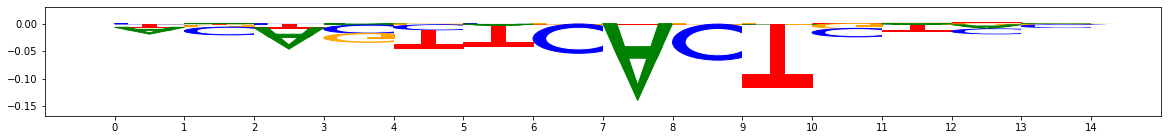

onehot, fwd and rev:


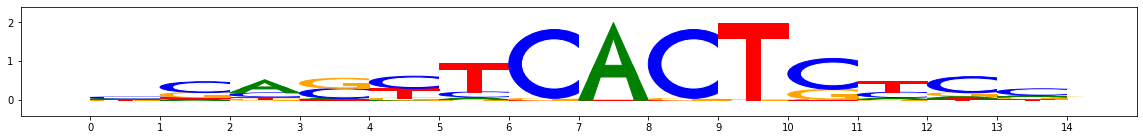

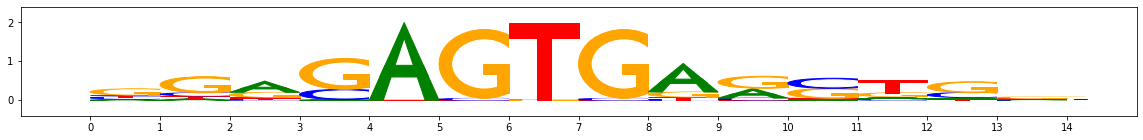

metacluster_1 pattern_3
total seqlets: 97
Task 0 hypothetical scores:


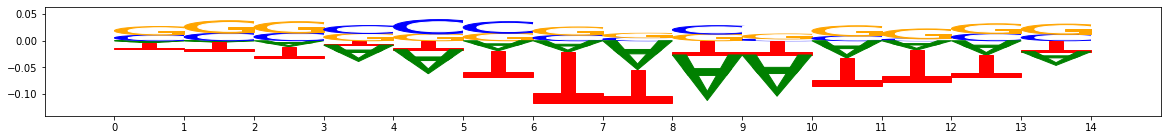

Task 0 actual importance scores:


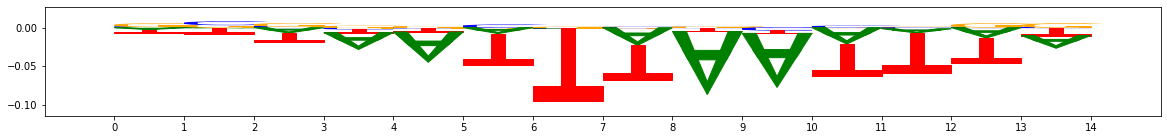

onehot, fwd and rev:


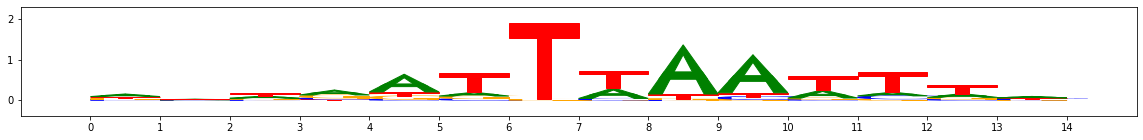

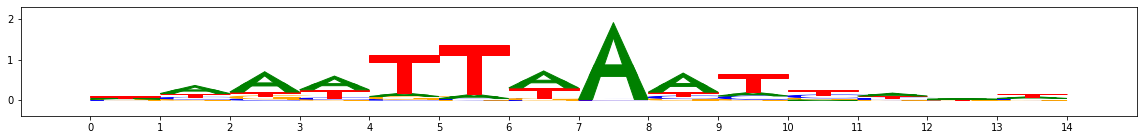

metacluster_1 pattern_4
total seqlets: 87
Task 0 hypothetical scores:


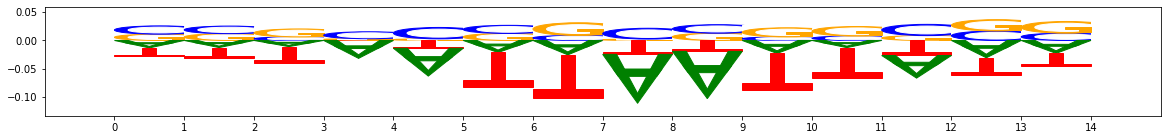

Task 0 actual importance scores:


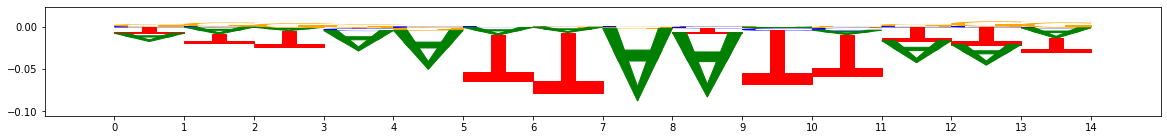

onehot, fwd and rev:


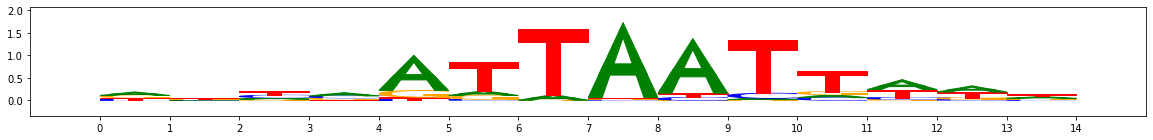

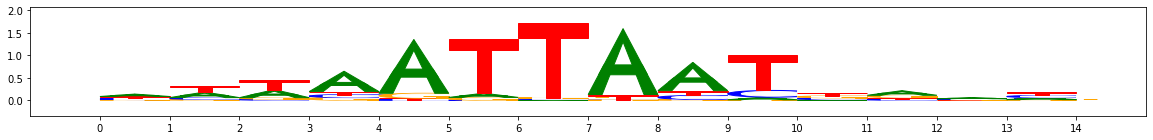

metacluster_1 pattern_5
total seqlets: 85
Task 0 hypothetical scores:


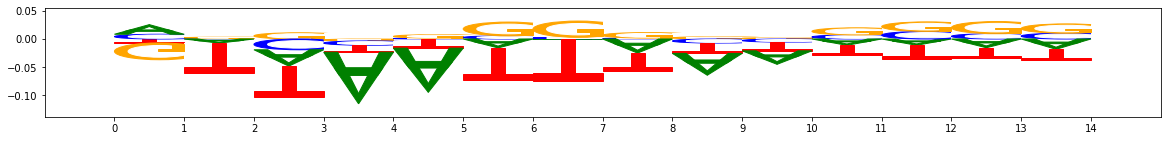

Task 0 actual importance scores:


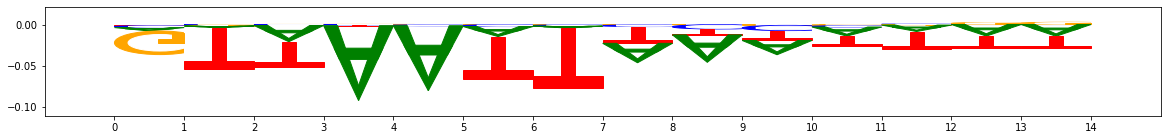

onehot, fwd and rev:


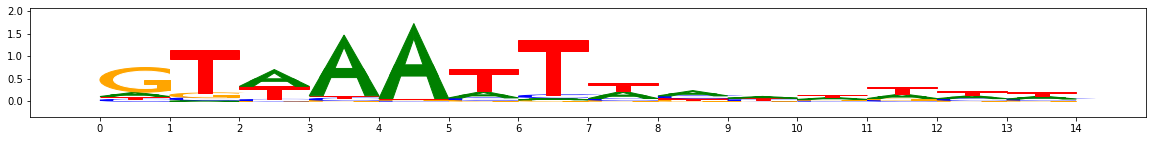

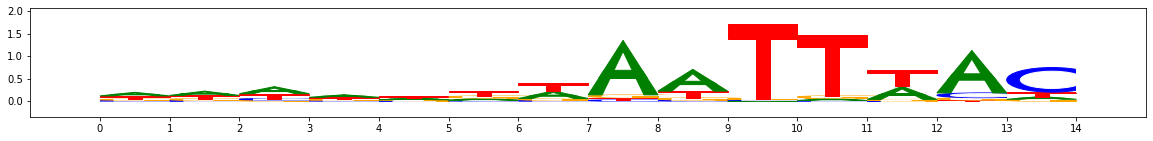

metacluster_1 pattern_6
total seqlets: 81
Task 0 hypothetical scores:


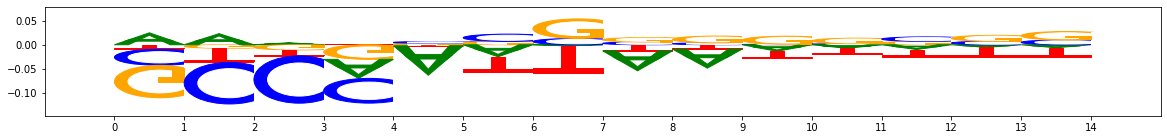

Task 0 actual importance scores:


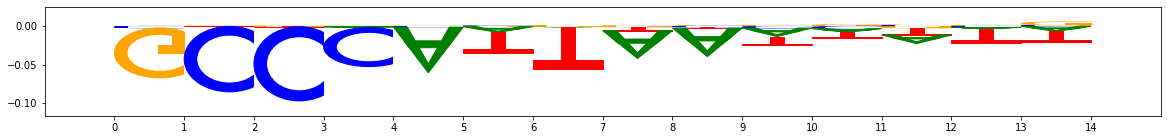

onehot, fwd and rev:


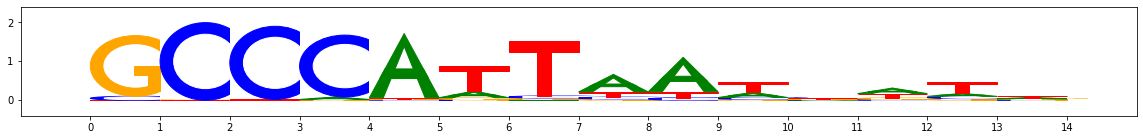

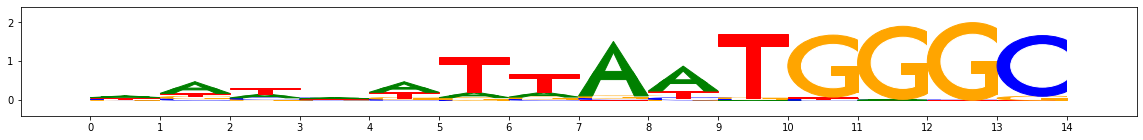

metacluster_1 pattern_7
total seqlets: 67
Task 0 hypothetical scores:


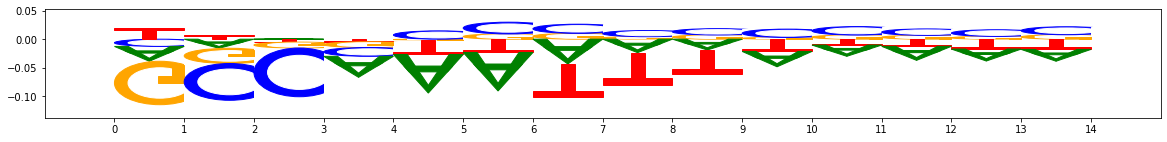

Task 0 actual importance scores:


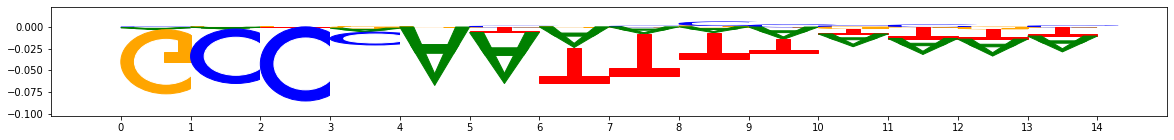

onehot, fwd and rev:


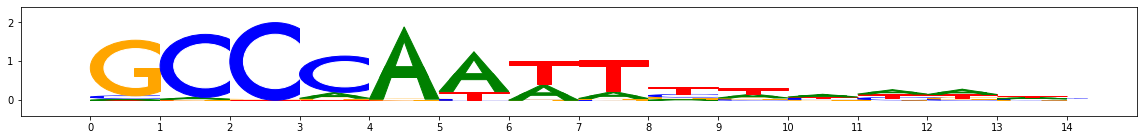

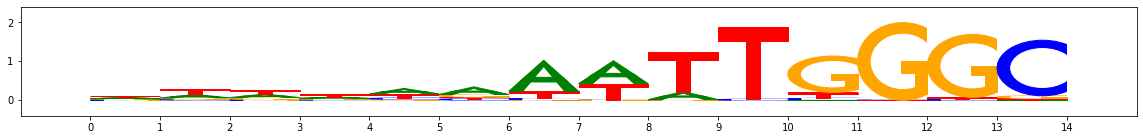

In [8]:
import h5py
from collections import Counter
import numpy as np

from modisco.visualization import viz_sequence
reload(viz_sequence)
from matplotlib import pyplot as plt

import modisco.affinitymat.core
reload(modisco.affinitymat.core)
import modisco.cluster.phenograph.core
reload(modisco.cluster.phenograph.core)
import modisco.cluster.phenograph.cluster
reload(modisco.cluster.phenograph.cluster)
import modisco.cluster.core
reload(modisco.cluster.core)
import modisco.aggregator
reload(modisco.aggregator)

hdf5_results = h5py.File("./results.hdf5","r")

print("Metaclusters heatmap")
import seaborn as sns
activity_patterns = np.array(hdf5_results['metaclustering_results']['attribute_vectors'])[
                    np.array(
        [x[0] for x in sorted(
                enumerate(hdf5_results['metaclustering_results']['metacluster_indices']),
               key=lambda x: x[1])])]
sns.heatmap(activity_patterns, center=0)
plt.show()

metacluster_names = [
    x.decode("utf-8") for x in 
    list(hdf5_results["metaclustering_results"]
         ["all_metacluster_names"][:])]

all_patterns = []
background = np.mean(onehot_data, axis=(0,1))
all_pwms = []

for metacluster_name in metacluster_names:
    print(metacluster_name)
    metacluster_grp = (hdf5_results["metacluster_idx_to_submetacluster_results"]
                                   [metacluster_name])
    print("activity pattern:",metacluster_grp["activity_pattern"][:])
    all_pattern_names = [x.decode("utf-8") for x in 
                         list(metacluster_grp["seqlets_to_patterns_result"]
                                             ["patterns"]["all_pattern_names"][:])]
    if (len(all_pattern_names)==0):
        print("No motifs found for this activity pattern")
    for pattern_name in all_pattern_names:
        print(metacluster_name, pattern_name)
        all_patterns.append((metacluster_name, pattern_name))
        pattern = metacluster_grp["seqlets_to_patterns_result"]["patterns"][pattern_name]
        print("total seqlets:",len(pattern["seqlets_and_alnmts"]["seqlets"]))
        print("Task 0 hypothetical scores:")
        viz_sequence.plot_weights(pattern["task0_hypothetical_contribs"]["fwd"])
        print("Task 0 actual importance scores:")
        viz_sequence.plot_weights(pattern["task0_contrib_scores"]["fwd"])
        #print("Task 1 hypothetical scores:")
        #viz_sequence.plot_weights(pattern["task1_hypothetical_contribs"]["fwd"])
        #print("Task 1 actual importance scores:")
        #viz_sequence.plot_weights(pattern["task1_contrib_scores"]["fwd"])
        #print("Task 2 hypothetical scores:")
        #viz_sequence.plot_weights(pattern["task2_hypothetical_contribs"]["fwd"])
        #print("Task 2 actual importance scores:")
        #viz_sequence.plot_weights(pattern["task2_contrib_scores"]["fwd"])
        print("onehot, fwd and rev:")
        viz_sequence.plot_weights(viz_sequence.ic_scale(np.array(pattern["sequence"]["fwd"]),
                                                        background=background)) 
        viz_sequence.plot_weights(viz_sequence.ic_scale(np.array(pattern["sequence"]["rev"]),
                                                        background=background))
        all_pwms.append(np.array(pattern["sequence"]["fwd"]))
        #Plot the subclustering too, if available
#         if ("subclusters" in pattern):
#             print("PLOTTING SUBCLUSTERS")
#             subclusters = np.array(pattern["subclusters"])
#             twod_embedding = np.array(pattern["twod_embedding"])
#             plt.scatter(twod_embedding[:,0], twod_embedding[:,1], c=subclusters, cmap="tab20")
#             plt.show()
#             for subcluster_name in list(pattern["subcluster_to_subpattern"]["subcluster_names"]):
#                 subpattern = pattern["subcluster_to_subpattern"][subcluster_name]
#                 print(subcluster_name.decode("utf-8"), "size", len(subpattern["seqlets_and_alnmts"]["seqlets"]))
#                 subcluster = int(subcluster_name.decode("utf-8").split("_")[1])
#                 plt.scatter(twod_embedding[:,0], twod_embedding[:,1], c=(subclusters==subcluster))
#                 plt.show()
#                 viz_sequence.plot_weights(subpattern["task0_hypothetical_contribs"]["fwd"])
#                 viz_sequence.plot_weights(subpattern["task0_contrib_scores"]["fwd"])
#                 viz_sequence.plot_weights(subpattern["sequence"]["fwd"])
        
hdf5_results.close()

## 7. Export Discovered Motifs (MEME Format)
Convert the discovered Position Weight Matrices (PWMs) into MEME format. This file can be used with external tools (e.g., TOMTOM, GO-Mo) to match discovered motifs against known databases.

In [9]:
with open('./sequence.meme','w') as f:
    f.write('MEME version 5.4.1\n\n'+'ALPHABET= ACGT\n\n'+'strands: + -\n\n'+'Background letter frequencies\n'+
        'A 0.25 C 0.25 G 0.25 T 0.25\n\n')
    for i,pwm in enumerate(all_pwms):
        f.write('MOTIF\tmotif_pfm'+str(i)+'\n')
        f.write('letter-probability matrix: alength= 4 w= {}\n'.format(pwm.shape[0]))
        np.savetxt(f, pwm, fmt='%.3f', delimiter='\t')
        f.write('\n')